# 1. Abertura e Introdução

A modelagem geométrica é o processo de representar matematicamente formas e objetos que serão exibidos em sistemas computacionais, como jogos digitais, programas de CAD e aplicações gráficas em geral. Um dos grandes desafios está em traduzir formas contínuas do mundo real para estruturas digitais, que são sempre discretas.

Uma abordagem comum é a modelagem poligonal, na qual objetos são descritos a partir de vértices, arestas e faces que formam malhas (mesh). Embora muito versátil, essa técnica apresenta limitações quando se deseja representar superfícies suavemente curvas, já que seria necessário aumentar muito o número de polígonos para obter uma boa aproximação.

Por outro lado, técnicas baseadas em curvas matemáticas, como as curvas de Bézier e as splines, permitem descrever superfícies suaves de forma eficiente, com poucos pontos de controle. Essas representações são fundamentais em áreas como design gráfico, tipografia, modelagem automotiva e animações por computador.

Nesta primeira parte, o objetivo é apresentar de forma visual a diferença entre representar uma forma geométrica simples (um círculo, por exemplo) utilizando polígonos versus curvas suaves.

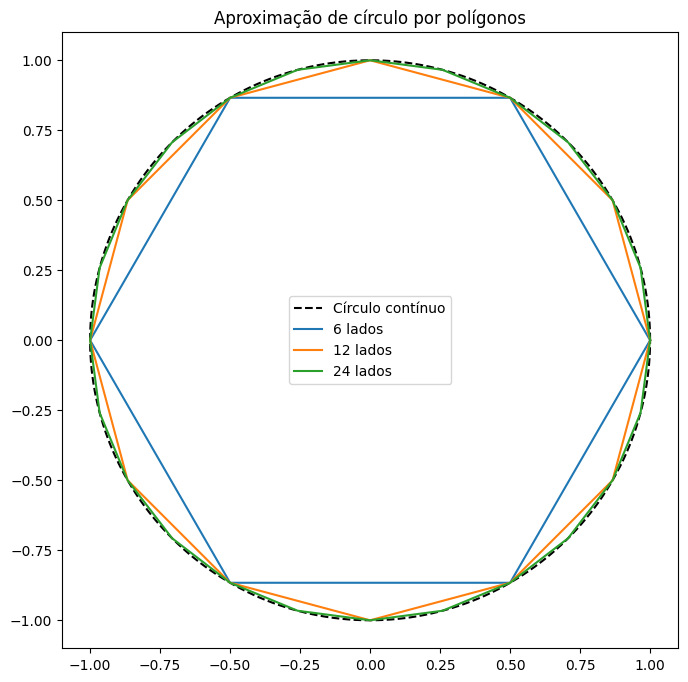

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definição de um círculo contínuo
theta = np.linspace(0, 2*np.pi, 500)
x_circle = np.cos(theta)
y_circle = np.sin(theta)

# Função para gerar polígonos regulares aproximando o círculo
def polygon_approx(n_sides):
    angles = np.linspace(0, 2*np.pi, n_sides, endpoint=False)
    x = np.cos(angles)
    y = np.sin(angles)
    return np.append(x, x[0]), np.append(y, y[0])

# Plotagem
plt.figure(figsize=(8,8))
plt.plot(x_circle, y_circle, 'k--', label='Círculo contínuo')

for n in [6, 12, 24]:
    x_poly, y_poly = polygon_approx(n)
    plt.plot(x_poly, y_poly, label=f'{n} lados')

plt.gca().set_aspect('equal')
plt.legend()
plt.title("Aproximação de círculo por polígonos")
plt.show()


## 1. Abertura e Introdução: explicação do código e fórmulas

**1) Objetivo e bibliotecas**  
O código usa `numpy` para computação vetorial e `matplotlib` para visualização 2D. A meta é comparar uma forma contínua com suas aproximações poligonais.

**2) Curva contínua do círculo**  
Parametrização clássica do círculo unitário:
$$
\theta \in [0,2\pi],\quad x(\theta)=\cos\theta,\quad y(\theta)=\sin\theta.
$$
Amostra-se um conjunto denso de valores de $\theta$ para que a curva pareça contínua no gráfico.

**3) Aproximação poligonal regular**  
Um polígono regular de $n$ lados inscrito no círculo unitário é obtido amostrando ângulos igualmente espaçados:
$$
\alpha_k=\frac{2\pi k}{n},\quad k=0,1,\ldots,n-1.
$$
Os vértices são:
$$
x_k=\cos\alpha_k,\quad y_k=\sin\alpha_k.
$$
Para fechar o contorno no plot repete-se o primeiro vértice ao final.

**4) O que o plot mostra**  
Plota-se o círculo contínuo como referência e, sobre ele, os polígonos para $n=6,12,24$. Visualmente observa-se a melhora da aproximação conforme $n$ cresce.

**5) Medida rápida do erro radial da aproximação**  
Para o polígono regular inscrito no círculo de raio $1$, o apótema vale $a=\cos\!\left(\frac{\pi}{n}\right)$. A discrepância radial máxima entre o círculo e o polígono ocorre no meio de uma aresta e é:
$$
\varepsilon_n = 1 - \cos\!\left(\frac{\pi}{n}\right)
\approx \frac{\pi^2}{2\,n^2}\quad\text{para } n \text{ grande.}
$$
Isso explica a convergência quadrática da aproximação radial com $n$.

**6) Perímetro e área do polígono inscrito**  
Perímetro:
$$
P_n = 2n\,\sin\!\left(\frac{\pi}{n}\right)\xrightarrow[n\to\infty]{} 2\pi.
$$
Área:
$$
A_n=\frac{n}{2}\,\sin\!\left(\frac{2\pi}{n}\right)\xrightarrow[n\to\infty]{} \pi,
$$
que são, respectivamente, o perímetro e a área do círculo unitário.

**7) Conclusão didática**  
Aumentar $n$ melhora a aproximação, mas a suavidade perfeita requer representações paramétricas. Nas próximas seções serão introduzidas curvas como Bézier e splines, que atingem superfícies suaves com poucos pontos de controle.



---



## 2. Modelagem poligonal e rasterização

### 2.1 Conceitos básicos

Uma malha poligonal é um par $(V, E)$ em que $V=\{ \mathbf{v}_i \}$ é um conjunto de vértices e $E$ é um conjunto de arestas que conectam pares de vértices. Polígonos são ciclos simples $(\mathbf{v}_0,\mathbf{v}_1,\ldots,\mathbf{v}_{n-1},\mathbf{v}_0)$ e superfícies podem ser compostas por faces triangulares ou quadriláteras.

Representação de uma polilinha com $n$ segmentos:
$$
\mathcal{P} = \left[\mathbf{v}_0,\mathbf{v}_1,\ldots,\mathbf{v}_n\right],\quad
E_i = \left(\mathbf{v}_i,\mathbf{v}_{i+1}\right).
$$

Limitação fundamental: superfícies suaves exigem muitos polígonos para aparentar continuidade. Em visualização discretizada, cada aresta contínua precisa tornar-se um conjunto de pixels sobre uma grade matricial. Esse processo é chamado de rasterização.

Exercício breve de intuição: comparar um círculo aproximado por polígonos com 6, 12 e 24 lados. O erro radial máximo para polígono regular inscrito de $n$ lados é
$$
\varepsilon_n = 1 - \cos\!\left(\frac{\pi}{n}\right) \approx \frac{\pi^2}{2n^2}\ \text{para } n \text{ grande.}
$$

### 2.2 Rasterização de retas com algoritmo do ponto médio

Objetivo: dado um segmento de reta do ponto inteiro $(x_0,y_0)$ ao ponto inteiro $(x_1,y_1)$, selecionar os pixels que melhor aproximam a reta ideal usando apenas aritmética inteira.

#### Derivação no primeiro octante

Assumir $0 \le m \le 1$ com $m = \frac{\Delta y}{\Delta x}$, onde
$$
\Delta x = x_1 - x_0,\quad \Delta y = y_1 - y_0,\quad \Delta x \ge \Delta y \ge 0.
$$

Definir a função implícita da reta que passa por $(x_0,y_0)$:
$$
f(x,y) = \Delta y\,(x - x_0) - \Delta x\,(y - y_0).
$$

No passo $k$, tendo escolhido o pixel $(x_k,y_k)$, os candidatos ao próximo pixel são $E=(x_k+1,y_k)$ e $NE=(x_k+1,y_k+1)$. A decisão é baseada no sinal de $f$ avaliado no ponto médio entre esses dois candidatos:
$$
p_k = f\!\left(x_k + 1,\ y_k + \tfrac{1}{2}\right).
$$

Regra de decisão e atualização inteira clássica:

\begin{aligned}
p_0 &= 2\Delta y - \Delta x,\\[2pt]
\text{se } p_k < 0 &:\ \text{escolha } E,\quad p_{k+1} = p_k + 2\Delta y,\\
\text{senão } &:\ \text{escolha } NE,\quad p_{k+1} = p_k + 2(\Delta y - \Delta x).
\end{aligned}


A cada iteração incrementa-se $x \leftarrow x+1$ e, quando o passo é $NE$, também $y \leftarrow y+1$.

#### Generalização para todos os octantes

Para qualquer par $(x_0,y_0)$ e $(x_1,y_1)$:

1. Calcular $\Delta x = |x_1-x_0|$ e $\Delta y = |y_1-y_0|$.
2. Determinar os passos de sinal $s_x = \operatorname{sgn}(x_1-x_0)$ e $s_y = \operatorname{sgn}(y_1-y_0)$.
3. Se $\Delta y \le \Delta x$, iterar em $x$ usando a regra do primeiro octante e aplicar $s_x$ e $s_y$. Caso contrário, trocar os papéis de $x$ e $y$ e iterar em $y$.

Essa estratégia mantém a decisão inteira e cobre todos os casos sem ponto flutuante.

Observação didática: arestas de polígonos na tela são sequências de pixels produzidas por esse algoritmo. Posteriormente, curvas suaves serão aproximadas por polilinhas cujas arestas também são rasterizadas com o ponto médio.



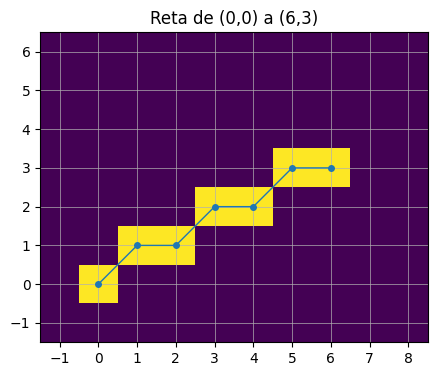

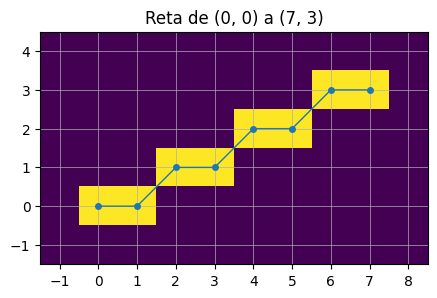

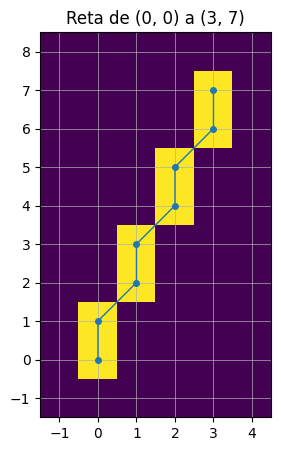

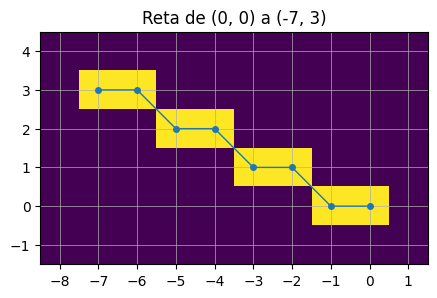

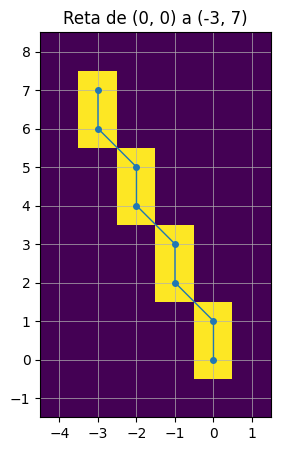

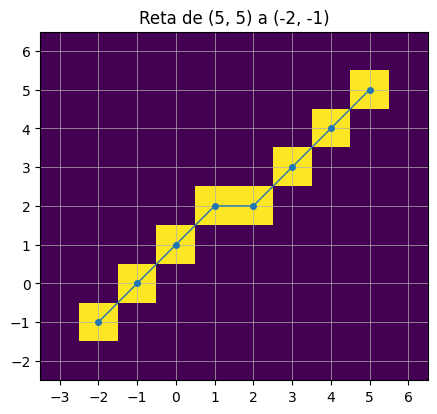

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def bresenham_line(x0, y0, x1, y1):
    """Algoritmo do ponto médio (Bresenham) para todos os octantes.
    Retorna lista de pixels (x, y) com aritmética inteira.
    """
    pixels = []

    dx = x1 - x0
    dy = y1 - y0

    sx = 1 if dx >= 0 else -1
    sy = 1 if dy >= 0 else -1

    dx = abs(dx)
    dy = abs(dy)

    # Caso 1: |m| <= 1, iterar em x
    if dx >= dy:
        d = 2*dy - dx  # p0
        x, y = x0, y0
        for _ in range(dx + 1):
            pixels.append((x, y))
            if d < 0:
                d += 2*dy
                x += sx
            else:
                d += 2*(dy - dx)
                x += sx
                y += sy
    # Caso 2: |m| > 1, iterar em y
    else:
        d = 2*dx - dy
        x, y = x0, y0
        for _ in range(dy + 1):
            pixels.append((x, y))
            if d < 0:
                d += 2*dx
                y += sy
            else:
                d += 2*(dx - dy)
                x += sx
                y += sy

    return pixels

def draw_pixel_grid(pixels, xlim=None, ylim=None, show_path=True, title="Rasterização por ponto médio"):
    """Desenha os pixels escolhidos sobre uma grade cartesiana (Y para cima)."""
    if not pixels:
        return

    xs, ys = zip(*pixels)
    xs = np.array(xs, dtype=int)
    ys = np.array(ys, dtype=int)

    if xlim is None:
        xlim = (int(xs.min()) - 1, int(xs.max()) + 1)
    if ylim is None:
        ylim = (int(ys.min()) - 1, int(ys.max()) + 1)

    # Mapa binário de pixels
    width  = xlim[1] - xlim[0] + 1
    height = ylim[1] - ylim[0] + 1
    img = np.zeros((height, width), dtype=int)

    for x, y in pixels:
        ix = x - xlim[0]
        iy = y - ylim[0]
        if 0 <= ix < width and 0 <= iy < height:
            img[iy, ix] = 1  # sem inverter Y

    plt.figure(figsize=(5, 5))
    plt.imshow(
        img,
        extent=[xlim[0]-0.5, xlim[1]+0.5, ylim[0]-0.5, ylim[1]+0.5],
        origin='lower',           # Y para cima
        interpolation='none'      # sem borrão
    )
    plt.grid(True, which='both', linewidth=0.5)
    plt.xticks(range(xlim[0], xlim[1] + 1))
    plt.yticks(range(ylim[0], ylim[1] + 1))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(title)

    if show_path:
        # Caminho ligando centros dos pixels
        plt.plot(xs, ys, marker='o', linewidth=1, markersize=4)

    plt.show()

# Demonstração 1: primeiro octante
pix1 = bresenham_line(0, 0, 6, 3)
draw_pixel_grid(pix1, xlim=(-1, 8), ylim=(-1, 6), title="Reta de (0,0) a (6,3)")

# Demonstração 2: todos os octantes
test_segments = [
    (0, 0, 7, 3),   # 0 <= m <= 1
    (0, 0, 3, 7),   # m > 1
    (0, 0, -7, 3),  # m negativo leve
    (0, 0, -3, 7),  # m negativo íngreme
    (5, 5, -2, -1), # quadrante oposto
]

for seg in test_segments:
    pix = bresenham_line(*seg)
    draw_pixel_grid(pix, title=f"Reta de {seg[:2]} a {seg[2:]}")


## Curvas de Bézier

### 1) Motivação e ideia geométrica

Uma curva de Bézier é determinada por pontos de controle
$$
(P_0, P_1, \ldots, P_n \in \mathbb{R}^d).
$$

O parâmetro
$$
(t \in [0,1])
$$

percorre a curva do primeiro ao último ponto de controle. Em cada t, o ponto

$$
(\mathbf{B}(t))
$$

é uma combinação convexa dos pontos de controle, o que garante que a curva permaneça dentro do fecho convexo do polígono de controle.

### 2) Definição por polinômios de Bernstein

Define-se a base de Bernstein de grau \(n\) por

$$
b_{i,n}(t) = \binom{n}{i}(1-t)^{n-i}t^{\,i}, \quad i=0,1,\ldots,n,\quad t\in[0,1].
$$

A curva de Bézier é
$$
\mathbf{B}(t) = \sum_{i=0}^{n} b_{i,n}(t)\,P_i.
$$

Propriedades fundamentais dos polinômios de Bernstein
$$
b_{i,n}(t) \ge 0 \quad \text{para } t\in[0,1],
\qquad
\sum_{i=0}^{n} b_{i,n}(t) = 1.
$$
Como consequência, $(\mathbf{B}(t))$ é combinação convexa dos $(P_i)$.

### 3) Propriedades essenciais da curva

Interpolação das extremidades
$$
\mathbf{B}(0)=P_0,
\qquad
\mathbf{B}(1)=P_n.
$$

Invariância afim
$$
A\big(\mathbf{B}(t)\big) = \sum_{i=0}^{n} b_{i,n}(t)\,A(P_i),
$$
para qualquer transformação afim \(A\). A construção é puramente linear, portanto respeita translações, rotações e mudanças de escala.

Derivada de ordem um
$$
\mathbf{B}'(t) = n \sum_{i=0}^{n-1} b_{i,n-1}(t)\,\big(P_{i+1}-P_i\big).
$$

Derivadas nas extremidades
$$
\mathbf{B}'(0) = n\,(P_1 - P_0),
\qquad
\mathbf{B}'(1) = n\,(P_n - P_{n-1}).
$$

Derivada de ordem dois
$$
\mathbf{B}''(t) = n(n-1)\sum_{i=0}^{n-2} b_{i,n-2}(t)\,\big(P_{i+2} - 2P_{i+1} + P_i\big).
$$

Estas expressões mostram que tangentes e curvatura locais dependem de diferenças finitas entre pontos de controle adjacentes.

### 4) Algoritmo de De Casteljau

A avaliação por De Casteljau usa apenas interpolações lineares e é numericamente estável.

Definições iniciais
$$
P_i^{(0)} = P_i, \quad i=0,\ldots,n.
$$

Recorrência para \(r=1,\ldots,n\) e \(i=0,\ldots,n-r\)
$$
P_i^{(r)}(t) = (1-t)\,P_i^{(r-1)}(t) + t\,P_{i+1}^{(r-1)}(t).
$$

O ponto na curva é
$$
\mathbf{B}(t) = P_0^{(n)}(t).
$$

A construção produz níveis intermediários $P_i^{(r)}$ que formam polígonos cada vez menores. Isto permite subdividir naturalmente a curva em $t=t_0$. Se $t_0$ é fixado, os pontos de controle do segmento esquerdo e do segmento direito são dados pelos elementos das bordas dos níveis gerados pelo mesmo processo.

Para uma curva cúbica com pontos $P_0,P_1,P_2,P_3$, escrevendo $t_0$ por brevidade

$$
\begin{aligned}
&Q_0 = (1-t_0)P_0 + t_0 P_1,\quad
Q_1 = (1-t_0)P_1 + t_0 P_2,\quad
Q_2 = (1-t_0)P_2 + t_0 P_3,\\
&R_0 = (1-t_0)Q_0 + t_0 Q_1,\quad
R_1 = (1-t_0)Q_1 + t_0 Q_2,\\
&S_0 = (1-t_0)R_0 + t_0 R_1.
\end{aligned}
$$

O ponto \(S_0\) está na curva. O segmento esquerdo tem pontos de controle \(\{P_0, Q_0, R_0, S_0\}\). O segmento direito tem pontos de controle \(\{S_0, R_1, Q_2, P_3\}\).

### 5) Elevação de grau

É possível representar a mesma curva com grau maior, o que melhora continuidade de junções em modelagem sem alterar a geometria. Dados $P_0,\ldots,P_n$, os novos pontos $\widehat{P}_0,\ldots,\widehat{P}_{n+1}$ de grau $n+1$ são

$$
\widehat{P}_0 = P_0,\quad
\widehat{P}_{n+1} = P_n,
$$
e para \(i=1,\ldots,n\)
$$
\widehat{P}_i = \frac{i}{n+1} P_{i-1} + \left(1 - \frac{i}{n+1}\right) P_i.
$$

### 6) Amostragem e aproximação por polilinhas

A curva é frequentemente renderizada por uma polilinha aproximante. Amostragem uniforme usa

$$
t_k = \frac{k}{m}, \quad k=0,1,\ldots,m,
\qquad
\mathbf{B}(t_k) = \sum_{i=0}^{n} b_{i,n}(t_k)\,P_i.
$$

Aproximações mais fiéis empregam subdivisão adaptativa por De Casteljau. Um critério simples usa a distância máxima dos pontos de controle à corda $P_0 P_n$. Se a distância excede uma tolerância, subdivide-se em $t=\tfrac{1}{2}$ e repete-se o processo nos subsegmentos.

### 7) Exemplo trabalhado curto

Considere uma curva quadrática com $P_0=(0,0)$, $P_1=(1,2)$, $P_2=(2,0)$. Em $t=\tfrac{1}{2}$

$$
b_{0,2}\!\left(\tfrac{1}{2}\right)=\tfrac{1}{4},\quad
b_{1,2}\!\left(\tfrac{1}{2}\right)=\tfrac{1}{2},\quad
b_{2,2}\!\left(\tfrac{1}{2}\right)=\tfrac{1}{4}.
$$

Logo

$$
\mathbf{B}\!\left(\tfrac{1}{2}\right)=\tfrac{1}{4}P_0+\tfrac{1}{2}P_1+\tfrac{1}{4}P_2=(1.0,1.0).
$$

A derivada na origem é

$$
\mathbf{B}'(0)=2\,(P_1-P_0)=(2,4).
$$

### 8) Exercícios guiados

a) Derivar a fórmula da primeira derivada usando

$$
\frac{d}{dt} b_{i,n}(t) = n\big(b_{i-1,n-1}(t) - b_{i,n-1}(t)\big),
$$

com a convenção $b_{-1,n-1}=b_{n,n-1}=0$. Em seguida obter $\mathbf{B}'(0)$ e $\mathbf{B}'(1)$.

b) Repetir o exemplo trabalhado para $t=\tfrac{1}{4}$ e $t=\tfrac{3}{4}$. Comparar a avaliação por Bernstein com a avaliação por De Casteljau.

c) Implementar a subdivisão em \(t=\tfrac{1}{2}\) para uma Bézier cúbica e listar explicitamente os pontos de controle dos segmentos esquerdo e direito pela construção de De Casteljau.

d) Projetar um esquema de amostragem adaptativa que interrompe quando a distância máxima de qualquer ponto de controle à corda das extremidades for menor que uma tolerância \(\varepsilon\). Justificar por que este critério está relacionado à planicidade local.


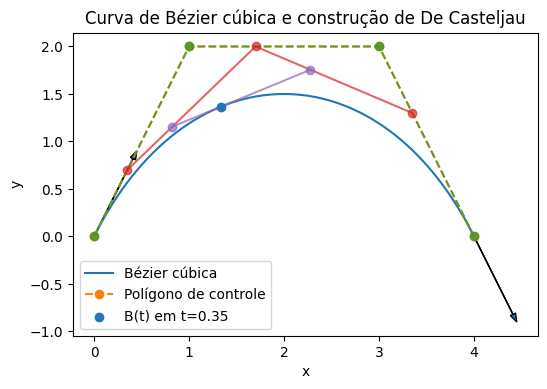

B(0.25) = (0.90625, 1.12500)
B(0.75) = (3.09375, 1.12500)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pontos de controle (alterar à vontade)
P0 = np.array([0.0, 0.0])
P1 = np.array([1.0, 2.0])
P2 = np.array([3.0, 2.0])
P3 = np.array([4.0, 0.0])
P = np.vstack([P0, P1, P2, P3])

def bezier_cubic(P, t):
    """
    Curva de Bézier cúbica via polinômios de Bernstein.
    P: array shape (4,2)
    t: escalar ou array em [0,1]
    retorna array shape (len(t), 2)
    """
    t = np.atleast_1d(t)
    one_t = 1.0 - t
    B = (one_t**3)[:, None]*P[0] \
        + (3*one_t**2*t)[:, None]*P[1] \
        + (3*one_t*t**2)[:, None]*P[2] \
        + (t**3)[:, None]*P[3]
    return B

def de_casteljau_levels(P, t):
    """
    Retorna os níveis intermediários do De Casteljau para um t dado.
    levels[0] = P (nível original), levels[1] = pontos do 1º nível, etc.
    """
    levels = [P.copy()]
    cur = P.copy()
    for k in range(1, 4):
        cur = (1 - t) * cur[:-1] + t * cur[1:]
        levels.append(cur)
    return levels  # níveis 0, 1, 2, 3

def bezier_tangent_endpoints(P):
    """Retorna as tangentes nas extremidades B'(0) e B'(1)."""
    d0 = 3*(P[1] - P[0])
    d1 = 3*(P[3] - P[2])
    return d0, d1

# Amostra densa da curva
ts = np.linspace(0.0, 1.0, 200)
B = bezier_cubic(P, ts)

# Ponto específico para visualizar De Casteljau
t_vis = 0.35
levels = de_casteljau_levels(P, t_vis)
B_t = levels[-1][0]  # ponto na curva no parâmetro escolhido

# Tangentes nas extremidades
d0, d1 = bezier_tangent_endpoints(P)

# Plot
plt.figure(figsize=(6, 5))
# Curva
plt.plot(B[:, 0], B[:, 1], label='Bézier cúbica')
# Polígono de controle
plt.plot(P[:, 0], P[:, 1], marker='o', linestyle='--', label='Polígono de controle')
# Construção de De Casteljau para t_vis
L0, L1, L2, L3 = levels
plt.plot(L0[:,0], L0[:,1], marker='o', linestyle='--', alpha=0.7)
plt.plot(L1[:,0], L1[:,1], marker='o', linestyle='-', alpha=0.7)
plt.plot(L2[:,0], L2[:,1], marker='o', linestyle='-', alpha=0.7)
plt.scatter(B_t[0], B_t[1], zorder=3, label=f'B(t) em t={t_vis:.2f}')

# Tangentes nas extremidades como setas curtas
scale = 0.15
plt.arrow(P[0,0], P[0,1], d0[0]*scale, d0[1]*scale, length_includes_head=True, head_width=0.06)
plt.arrow(P[3,0], P[3,1], d1[0]*scale, d1[1]*scale, length_includes_head=True, head_width=0.06)

plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title('Curva de Bézier cúbica e construção de De Casteljau')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Conferência numérica dos pontos do exemplo da seção
for t_test in [0.25, 0.75]:
    Bt = bezier_cubic(P, t_test)[0]
    print(f"B({t_test}) = ({Bt[0]:.5f}, {Bt[1]:.5f})")


## Explicação do código Bézier cúbica

1. **Importação de bibliotecas**  
   - `numpy` é usado para cálculos vetoriais e manipulação de arrays.  
   - `matplotlib.pyplot` é usado para visualização da curva, dos pontos de controle e da construção de De Casteljau.  

2. **Definição dos pontos de controle**  
   - Quatro pontos 2D são criados: `P0`, `P1`, `P2`, `P3`.  
   - Esses pontos são organizados em uma matriz `P` de forma `(4,2)`, representando o polígono de controle da Bézier cúbica.  

3. **Função `bezier_cubic(P, t)`**  
   - Implementa a equação de Bézier cúbica via polinômios de Bernstein.  
   - Calcula  
     $$
     B(t) = (1-t)^3 P_0 + 3(1-t)^2 t P_1 + 3(1-t) t^2 P_2 + t^3 P_3
     $$  
   - Aceita um escalar ou um array de valores de \(t \in [0,1]\).  
   - Retorna um array com as coordenadas correspondentes da curva.  

4. **Função `de_casteljau_levels(P, t)`**  
   - Implementa o algoritmo de De Casteljau.  
   - Retorna todos os níveis intermediários da construção:  
     - `levels[0]`: pontos originais.  
     - `levels[1]`: interpolações de primeira ordem.  
     - `levels[2]`: interpolações de segunda ordem.  
     - `levels[3]`: ponto único na curva para o valor de \(t\).  

5. **Função `bezier_tangent_endpoints(P)`**  
   - Calcula as tangentes nas extremidades usando as fórmulas:  
     $$
     B'(0) = 3(P_1 - P_0), \qquad B'(1) = 3(P_3 - P_2)
     $$  
   - Retorna dois vetores correspondentes às tangentes inicial e final.  

6. **Amostragem da curva**  
   - `ts = np.linspace(0.0, 1.0, 200)` gera 200 valores uniformemente espaçados de \(t\).  
   - `B = bezier_cubic(P, ts)` calcula os pontos da curva.  

7. **Construção de De Casteljau em um ponto específico**  
   - Define `t_vis = 0.35`.  
   - Usa `de_casteljau_levels` para obter os pontos intermediários.  
   - O último nível fornece `B_t`, o ponto na curva nesse parâmetro.  

8. **Tangentes nas extremidades**  
   - Usa `bezier_tangent_endpoints(P)` para calcular as direções de saída e chegada da curva.  
   - São desenhadas como pequenas setas no gráfico.  

9. **Plotagem com Matplotlib**  
   - A curva Bézier é desenhada em azul.  
   - O polígono de controle é desenhado em tracejado com marcadores.  
   - Os níveis de De Casteljau também são plotados para visualização.  
   - `plt.scatter` marca o ponto `B_t`.  
   - `plt.arrow` desenha as tangentes nas extremidades.  
   - Configura título, legenda, rótulos de eixos e aspecto igual no gráfico.  

10. **Conferência numérica**  
    - Para \(t = 0.25\) e \(t = 0.75\), a função `bezier_cubic` é chamada.  
    - Imprime as coordenadas desses pontos, permitindo validar os cálculos teóricos feitos na seção anterior.



---



## Splines e NURBS

### 1) O que são Splines?

- Pense numa régua flexível que passa por vários pontos.  
- Cada pedacinho da curva é ajustado por um polinômio simples, e todos esses pedacinhos se juntam de forma suave.  
- Esses pedacinhos chamamos de **splines**.

Na prática, em vez de uma única curva de Bézier gigante com 20 pontos (que ficaria impossível de controlar), usamos várias curvas menores ligadas de maneira suave.

---

### 2) Tipos de continuidade

Quando juntamos curvas, precisamos decidir se a junção será suave ou não.

- **Continuidade \(C^0\):** só garante que as curvas se encontrem.  
  (a curva não fica “quebrada”, mas pode mudar de direção bruscamente).  

- **Continuidade \(C^1\):** garante que além de se encontrar, a direção da tangente é a mesma nos dois lados.  
  (curva não tem “quina”).  

- **Continuidade \(C^2\):** garante que a curvatura também é suave.  
  (sem solavancos, curva ainda mais lisa).  

Na lousa: desenhar duas curvas se encontrando, uma com quina (C0), outra suave (C1), outra bem lisa (C2).

---

### 3) B-Splines

As **B-splines** são uma forma organizada de construir splines.  
Elas funcionam com uma coisa chamada **vetor de nós**, que decide em que trechos cada pedacinho vale.

A curva é definida assim:

$$
C(u) = \sum_{i=0}^{n} N_{i,p}(u)\,P_i
$$

- \(P_i\): pontos de controle.  
- \(N_{i,p}(u)\): funções base (recursivas), que fazem o mesmo papel dos polinômios de Bernstein.  
- \(p\): grau do spline (ex: cúbico, \(p=3\)).  

Intuição: cada \(N_{i,p}(u)\) é um “peso” que vale mais em um certo intervalo e menos em outros. A soma de todos os pesos é sempre 1.

---

### 4) NURBS – a evolução

**NURBS** significa *Non-Uniform Rational B-Splines*.  
É a ferramenta padrão em modelagem 3D (AutoCAD, Rhino, Maya, Blender).  

A diferença é que cada ponto de controle \(P_i\) tem um **peso** \(w_i\).  
A curva fica:

$$
C(u) = \frac{\sum_{i=0}^{n} N_{i,p}(u)\,w_i\,P_i}{\sum_{i=0}^{n} N_{i,p}(u)\,w_i}
$$

- Se todos os pesos são iguais → curva é uma B-spline comum.  
- Se mudamos um peso → esse ponto de controle puxa mais ou menos a curva.  
- Com os pesos certos, dá pra representar arcos de círculo e outras formas exatas que Bézier e B-splines comuns não conseguem.

---

### 5) Resumindo

- Bézier: curva suave puxada por pontos de controle.  
- Splines: várias Bézier menores costuradas suavemente.  
- B-splines: versão organizada e poderosa dos splines.  
- NURBS: versão com pesos, usada em praticamente toda modelagem 3D.

---

### 6) Exercícios guiados

1. Desenhe duas curvas que se encontram. Mostre quando a junção é C0 (quebrada), C1 (suave) e C2 (bem lisa).  
2. Faça uma B-spline cúbica com 5 pontos de controle. Explique que cada pedacinho só é influenciado por 4 pontos de cada vez.  
3. Mostre uma NURBS simples com 3 pontos: aumente o peso de um deles e desenhe como a curva é puxada.  


In [ ]:
# ------------------------------------------------------------
# B-splines e NURBS em Python puro (sem bibliotecas gráficas)
# - Vetor de nós aberto uniforme
# - Avaliação por De Boor (B-spline)
# - NURBS via coordenadas homogêneas
# - Amostragem e "visualização" ASCII
# - Exemplos práticos prontos para rodar
# ------------------------------------------------------------

from math import isclose
from typing import List, Tuple

Point = Tuple[float, float]

# ---------- utilidades vetoriais ----------
def add(p: Point, q: Point) -> Point:
    return (p[0] + q[0], p[1] + q[1])

def scale(a: float, p: Point) -> Point:
    return (a * p[0], a * p[1])

# ---------- vetor de nós aberto uniforme ----------
def uniform_open_knot_vector(n_ctrl: int, degree: int) -> List[float]:
    """
    Retorna vetor de nós aberto uniforme (não decrescente).
    Tamanho = n_ctrl + degree + 1.
    Ex.: n_ctrl=5, degree=3 -> len(knots)=9 => [0,0,0,0, 1/2, 1, 1,1,1]
    """
    p = degree
    m = n_ctrl + p + 1
    U = [0.0] * (p + 1)                 # repetição inicial
    interior = n_ctrl - p - 1
    if interior > 0:
        step_count = interior + 1
        for j in range(1, step_count):
            U.append(j / step_count)    # nós internos uniformes
    U += [1.0] * (p + 1)                # repetição final
    assert len(U) == m, f"Esperado {m} nós, obtido {len(U)}"
    return U

# ---------- busca de span (Piegl & Tiller) ----------
def find_span(n: int, p: int, u: float, U: List[float]) -> int:
    """
    Encontra índice do span tal que U[k] <= u < U[k+1].
    n = n_ctrl - 1, p = grau, U = nós.
    """
    if u >= U[n+1]:
        return n
    if u <= U[p]:
        return p
    low = p
    high = n + 1
    mid = (low + high) // 2
    while u < U[mid] or u >= U[mid + 1]:
        if u < U[mid]:
            high = mid
        else:
            low = mid
        mid = (low + high) // 2
    return mid

# ---------- De Boor (avaliação B-spline) ----------
def deboor(ctrl: List[Point], degree: int, knots: List[float], u: float) -> Point:
    """
    Avalia B-spline em u pelo algoritmo de De Boor.
    ctrl: lista de pontos (x,y)
    degree: grau p
    knots: vetor de nós
    u: parâmetro no domínio [U[p], U[n+1]]
    """
    p = degree
    n = len(ctrl) - 1
    k = find_span(n, p, u, knots)
    d = [ctrl[j] for j in range(k - p, k + 1)]  # cópia local
    for r in range(1, p + 1):
        for j in range(p, r - 1, -1):
            i = k - p + j
            denom = knots[i + p + 1 - r] - knots[i]
            alpha = 0.0 if isclose(denom, 0.0) else (u - knots[i]) / denom
            d[j] = add(scale(1 - alpha, d[j - 1]), scale(alpha, d[j]))
    return d[p]

def sample_bspline(ctrl: List[Point], degree: int, knots: List[float], m: int) -> List[Point]:
    """
    Amostra m+1 pontos uniformes no domínio válido [U[p], U[n+1]].
    """
    U = knots
    u0, u1 = U[degree], U[len(ctrl)]
    return [deboor(ctrl, degree, knots, u0 + (u1 - u0) * (k / m)) for k in range(m + 1)]

# ---------- NURBS (forma racional) ----------
def nurbs_point(ctrl: List[Point], weights: List[float], degree: int, knots: List[float], u: float) -> Point:
    """
    Avalia NURBS usando De Boor em coordenadas homogêneas.
    """
    Pw = [(c[0] * w, c[1] * w, w) for c, w in zip(ctrl, weights)]
    p = degree
    n = len(Pw) - 1
    U = knots
    k = find_span(n, p, u, U)
    d = [Pw[j] for j in range(k - p, k + 1)]
    for r in range(1, p + 1):
        for j in range(p, r - 1, -1):
            i = k - p + j
            denom = U[i + p + 1 - r] - U[i]
            alpha = 0.0 if isclose(denom, 0.0) else (u - U[i]) / denom
            d[j] = (
                (1 - alpha) * d[j - 1][0] + alpha * d[j][0],
                (1 - alpha) * d[j - 1][1] + alpha * d[j][1],
                (1 - alpha) * d[j - 1][2] + alpha * d[j][2],
            )
    Xw = d[p]
    w = Xw[2]
    return (Xw[0] / w, Xw[1] / w)

def sample_nurbs(ctrl: List[Point], weights: List[float], degree: int, knots: List[float], m: int) -> List[Point]:
    U = knots
    u0, u1 = U[degree], U[len(ctrl)]
    return [nurbs_point(ctrl, weights, degree, knots, u0 + (u1 - u0) * (k / m)) for k in range(m + 1)]

# ---------- "visualização" ASCII ----------
def ascii_canvas(points: List[Point], width: int = 70, height: int = 18, margin: float = 0.1, char: str = "*") -> str:
    """
    Renderiza uma polilinha como ASCII em uma grade width x height.
    """
    if not points:
        return ""
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)
    dx = xmax - xmin if xmax > xmin else 1.0
    dy = ymax - ymin if ymax > ymin else 1.0
    xmin -= margin * dx; xmax += margin * dx
    ymin -= margin * dy; ymax += margin * dy
    grid = [[" " for _ in range(width)] for _ in range(height)]
    for x, y in points:
        u = (x - xmin) / (xmax - xmin)
        v = (y - ymin) / (ymax - ymin)
        col = int(u * (width - 1))
        row = int((1 - v) * (height - 1))
        if 0 <= row < height and 0 <= col < width:
            grid[row][col] = char
    return "\n".join("".join(row) for row in grid)

# ============================================================
# Demonstrações
# ============================================================
if __name__ == "__main__":
    # ---- Exemplo base: B-spline cúbica (p=3) ----
    ctrl = [(0.0, 0.0), (1.0, 2.0), (3.0, 2.0), (4.0, 0.0), (5.0, -1.0)]
    p = 3
    U = uniform_open_knot_vector(len(ctrl), p)
    bs = sample_bspline(ctrl, p, U, m=60)

    print("B-spline cúbica - primeiros 5 pontos:")
    for pt in bs[:5]:
        print(f"({pt[0]:.4f}, {pt[1]:.4f})")
    print("\nPrévia ASCII - B-spline:")
    print(ascii_canvas(bs, width=70, height=18))

    # ---- Exemplo NURBS: mesmos ctrl com pesos ----
    weights = [1.0, 2.0, 3.0, 2.0, 1.0]  # ponto do meio puxa mais
    nu = sample_nurbs(ctrl, weights, p, U, m=60)

    print("\nNURBS (mesmos ctrl, pesos distintos) - primeiros 5 pontos:")
    for pt in nu[:5]:
        print(f"({pt[0]:.4f}, {pt[1]:.4f})")
    print("\nPrévia ASCII - NURBS:")
    print(ascii_canvas(nu, width=70, height=18))

    # ---- Intuição de suavidade: alterando um ponto interno ----
    ctrl_C0 = ctrl[:]
    ctrl_C1 = ctrl[:]
    ctrl_C2 = ctrl[:]
    ctrl_C0[2] = (ctrl_C0[2][0], ctrl_C0[2][1] + 2.0)  # mudança mais brusca
    ctrl_C1[2] = (ctrl_C1[2][0], ctrl_C1[2][1] + 0.8)  # mudança moderada
    ctrl_C2[2] = (ctrl_C2[2][0], ctrl_C2[2][1] + 0.2)  # mudança suave

    bs_C0 = sample_bspline(ctrl_C0, p, U, m=40)
    bs_C1 = sample_bspline(ctrl_C1, p, U, m=40)
    bs_C2 = sample_bspline(ctrl_C2, p, U, m=40)

    print("\nSuavidade (alterando P2): C0-like / C1-like / C2-like (qualitativo)")
    print("C0-like:")
    print(ascii_canvas(bs_C0, width=70, height=10))
    print("\nC1-like:")
    print(ascii_canvas(bs_C1, width=70, height=10))
    print("\nC2-like:")
    print(ascii_canvas(bs_C2, width=70, height=10))


B-spline cúbica - primeiros 5 pontos:
(0.0000, 0.0000)
(0.1000, 0.1934)
(0.1999, 0.3738)
(0.2998, 0.5415)
(0.3994, 0.6969)

Prévia ASCII - B-spline:
                                                                      
                      ************                                    
                   ***            ****                                
                ***                   ***                             
             **                          **                           
            *                              **                         
          **                                 **                       
         *                                     **                     
        *                                        **                   
      *                                           **                  
     *                                              **                
                                                      **              

## Entendendo o código de B-splines e NURBS

### 1) Ideia geral
O código implementa **curvas suaves** chamadas **B-splines** e **NURBS** sem usar bibliotecas gráficas.  
A lógica é sempre a mesma:  
- temos pontos de controle,  
- temos um grau (por exemplo cúbico, grau 3),  
- e temos um **vetor de nós** que controla onde cada pedacinho da curva atua.  

### 2) Vetor de nós
- É como uma régua que marca onde cada "polinômio base" vale.  
- No código, usamos um **vetor aberto uniforme**:  
  - começa com zeros repetidos,  
  - termina com uns repetidos,  
  - tem valores igualmente espaçados no meio.  

Isso garante que a curva começa no primeiro ponto e termina no último.

### 3) Algoritmo de De Boor
- É o "De Casteljau das B-splines".  
- Em vez de usar fórmulas cheias de coeficientes, o De Boor calcula pontos na curva fazendo **interpolações sucessivas** entre pontos de controle, usando o vetor de nós como guia.  
- O resultado é sempre estável numericamente e funciona para qualquer grau \(p\).  

### 4) NURBS
- São como B-splines, mas cada ponto de controle tem um **peso**.  
- Fórmula básica:

$$
C(u) = \frac{\sum N_{i,p}(u) \, w_i \, P_i}{\sum N_{i,p}(u) \, w_i}
$$

- Se todos os pesos são iguais, temos uma B-spline comum.  
- Se um ponto tem peso maior, ele **puxa mais forte a curva**.  
- É assim que softwares de modelagem 3D conseguem desenhar arcos de círculo e outras formas exatas.

### 5) Visualização ASCII
- Como não estamos usando gráficos, os pontos calculados da curva são desenhados numa **grade de caracteres**.  
- Cada ponto vira um `*` no lugar certo da tela.  
- Isso ajuda a "ver" a curva mesmo no terminal ou no notebook sem gráficos.

### 6) Exemplos inclusos
- **B-spline cúbica** com 5 pontos de controle.  
- **NURBS** com os mesmos pontos mas pesos diferentes → a curva muda de forma.  
- **Intuição de suavidade (C0, C1, C2)**: alterando um ponto interno de maneiras diferentes, dá pra comparar curvas mais "quebradas" e mais "lisas".

---

### 7) Resumindo
- **B-splines** = várias curvas suaves controladas por pontos + vetor de nós.  
- **De Boor** = método geométrico para calcular pontos da curva.  
- **NURBS** = B-splines com pesos → mais flexibilidade, usadas em CAD/3D.  
- **ASCII** = jeitinho de visualizar no terminal sem precisar de plot.

Esse código te dá a base pra experimentar mexendo nos pontos de controle, no grau da curva e nos pesos, e ver como a curva muda.


# Situação-problema: Renderizar um logo simples em uma matriz de LEDs

## Enunciado
Deseja-se desenhar, em uma matriz **20 × 12** de LEDs, um mini-logo composto por:

1. Um arco superior modelado por **uma Bézier cúbica**.  
2. Uma “calda” à direita modelada por **uma B-spline cúbica**.  
3. A curva inteira deve ser convertida em pixels acesos usando o **algoritmo de rasterização por ponto médio** para segmentos de reta.

---

### Dados

**Bézier cúbica do arco**  
- Pontos de controle:  
  $P_0=(2,2)$, $P_1=(4,6)$, $P_2=(8,6)$, $P_3=(10,2)$.

**B-spline cúbica da calda**  
- Pontos de controle:  
  $Q_0=(10,2)$, $Q_1=(12,1)$, $Q_2=(14,3)$, $Q_3=(16,2)$, $Q_4=(18,2)$.  
- Grau: $p=3$.  
- Vetor de nós aberto uniforme com um nó interno:  
  $[0,0,0,0,\;0.5,\;1,1,1,1]$.

---

### O que fazer

a) Avaliar a Bézier cúbica nos parâmetros $t=0,\,0.25,\,0.5,\,0.75,\,1$.  
   Mostrar as contas dos pesos de Bernstein e dos pontos resultantes.

b) Avaliar a B-spline em $u=0.25,\;0.5,\;0.75$ usando o **algoritmo de De Boor**.  
   Mostrar ao menos um cálculo completo (para $u=0.25$) com os coeficientes $alpha$.

c) Quantizar todos os pontos obtidos para a grade de pixels, arredondando ao inteiro mais próximo.  
   Conectar pontos consecutivos com segmentos de reta.

d) Rasterizar com **ponto médio** dois segmentos representativos, passo a passo, listando as decisões.  
   Para os demais, apenas apresentar o conjunto final de pixels.

e) Concluir com a **lista de pixels** a acender para compor o logo.




---

